# Notebook 03: Eckart 势模拟 + 解析对比

## 高斯波包入射 Eckart 势的含时演化

---

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from config import SimParams
from potentials import get_potential
from propagator import propagate
from observables import eckart_analytical_T_simple
from visualization import (
    set_style, plot_snapshots, plot_TR_evolution,
    plot_momentum_spectrum, plot_eckart_comparison
)

set_style()

## 1. Eckart 势特性

$$V(x) = \frac{V_0}{\cosh^2[\alpha(x - x_c)]}$$

- 光滑势，无穷远处指数衰减
- 有效宽度 ~ $1/\alpha$
- **存在精确解析透射系数**：

$$T(E) = \frac{1}{1 + \cosh^2(\pi s) / \sinh^2(\pi k / \alpha)}$$

其中 $k = \sqrt{2E}$，$s = \sqrt{2V_0/\alpha^2 - 1/4}$

In [2]:
p_eckart = SimParams(V0=10.0, k0=5.0, alpha=1.0, x_c=0.0, sigma=10.0)
print(f'V0 = {p_eckart.V0}, α = {p_eckart.alpha}, E_kinetic = {p_eckart.E_kinetic:.2f}')
s = np.sqrt(2*p_eckart.V0/p_eckart.alpha**2 - 0.25)
k = p_eckart.k0
T_anal = eckart_analytical_T_simple(np.array([p_eckart.E_kinetic]), p_eckart.V0, p_eckart.alpha)[0]
print(f'解析透射系数 T(E={p_eckart.E_kinetic:.2f}) = {T_anal:.6f}')
print(f's = {s:.4f}, πk/α = {np.pi*k/p_eckart.alpha:.4f}, πs = {np.pi*s:.4f}')

V0 = 10.0, α = 1.0, E_kinetic = 12.50
解析透射系数 T(E=12.50) = 0.970483
s = 4.4441, πk/α = 15.7080, πs = 13.9615


C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3132509093.py:24: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3132509093.py:24: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3132509093.py:24: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3132509093.py:24: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3132509093.py:24: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3132509093.py:24: UserWarning: Glyph 31995 (\

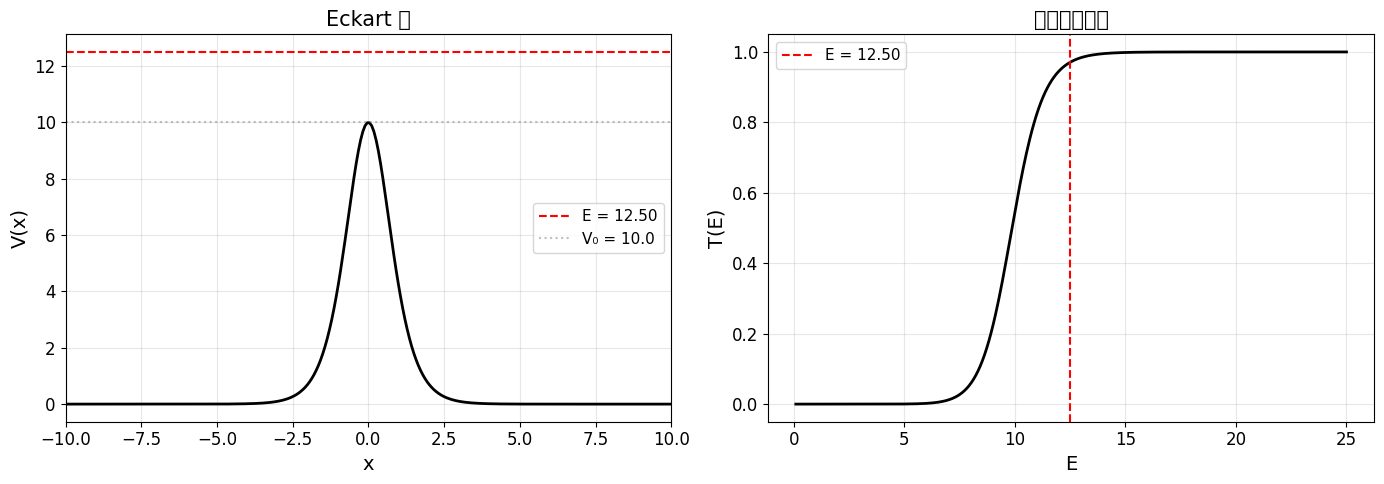

In [3]:
x = p_eckart.x
V = np.real(get_potential(x, p_eckart, 'eckart', with_cap=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x, V, 'k-', linewidth=2)
ax1.axhline(p_eckart.E_kinetic, color='r', linestyle='--', label=f'E = {p_eckart.E_kinetic:.2f}')
ax1.axhline(p_eckart.V0, color='gray', linestyle=':', alpha=0.5, label=f'V₀ = {p_eckart.V0}')
ax1.set_xlabel('x')
ax1.set_ylabel('V(x)')
ax1.set_title('Eckart 势')
ax1.set_xlim(-10, 10)
ax1.legend()

E_range = np.linspace(0.1, 2.5 * p_eckart.V0, 500)
T_range = eckart_analytical_T_simple(E_range, p_eckart.V0, p_eckart.alpha)
ax2.plot(E_range, T_range, 'k-', linewidth=2)
ax2.axvline(p_eckart.E_kinetic, color='r', linestyle='--', label=f'E = {p_eckart.E_kinetic:.2f}')
ax2.set_xlabel('E')
ax2.set_ylabel('T(E)')
ax2.set_title('解析透射系数')
ax2.legend()

plt.tight_layout()
plt.show()

## 2. 含时演化模拟

**注意**：解析透射系数 $T(E)$ 对应平面波（无限宽波包），而数值模拟使用有限宽高斯波包。
为使数值结果逼近解析解，我们取 $\sigma = 10$（宽波包，接近平面波极限）。
窄波包（$\sigma = 3$）因动量展宽较大，透射率会偏离平面波结果。

In [4]:
result_eckart = propagate(p_eckart, 'eckart')

In [5]:
print(f'数值透射率: T = {result_eckart.T_values[-1]:.6f}')
print(f'解析透射率: T = {T_anal:.6f}')
print(f'相对误差: {abs(result_eckart.T_values[-1] - T_anal)/T_anal * 100:.4f}%')

数值透射率: T = 0.969472
解析透射率: T = 0.970483
相对误差: 0.1042%


### 波包演化快照

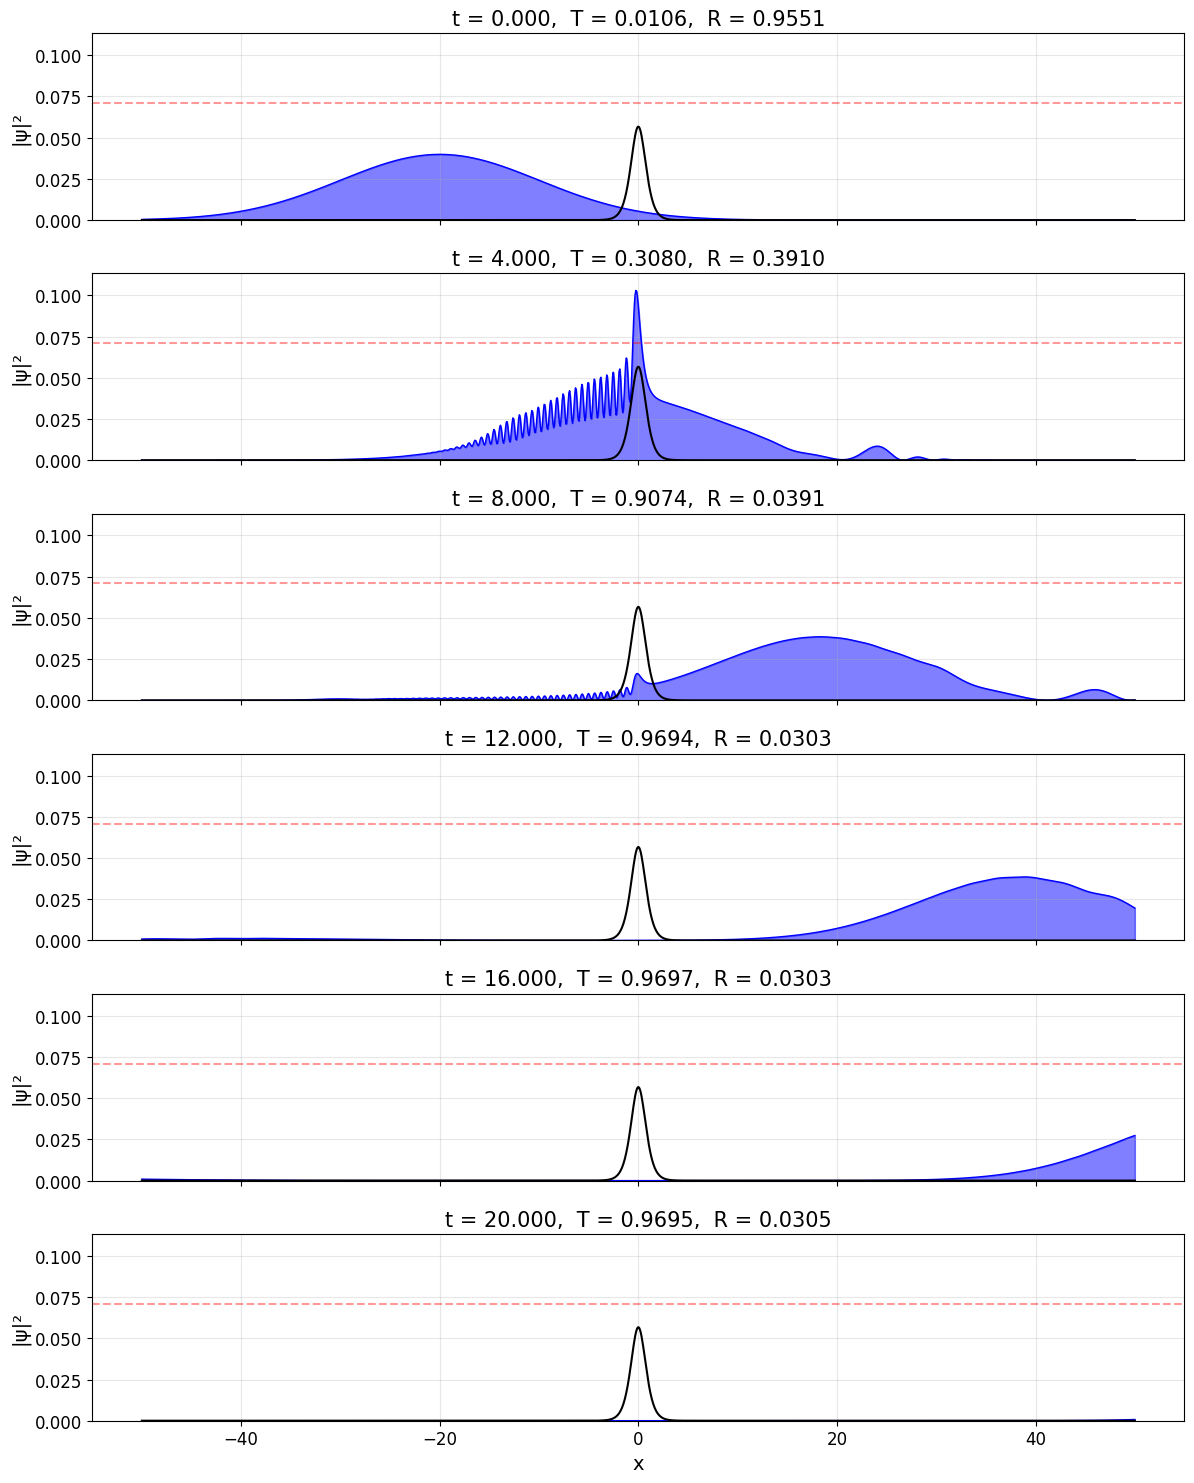

In [6]:
fig = plot_snapshots(result_eckart, n_snapshots=6, x_range=(-50, 50))
plt.show()

### T/R 演化

C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 28436 (\N{CJK UNIFIED IDEOGRAPH-6F14}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\Op

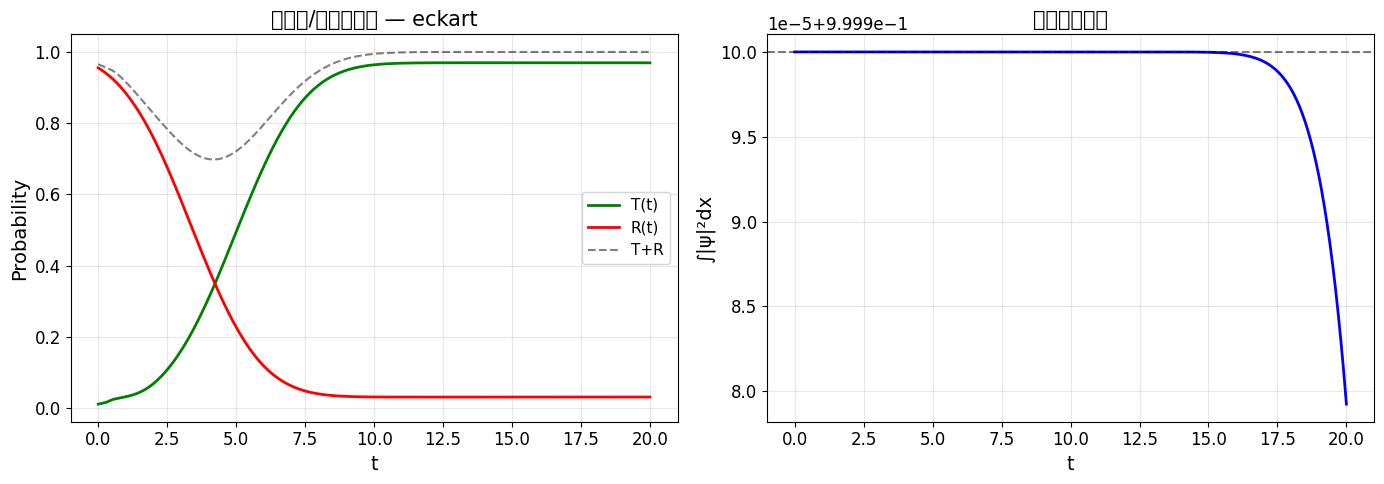

In [7]:
fig = plot_TR_evolution(result_eckart)
plt.show()

### 解析 vs 数值对比

C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:215: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:215: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:215: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:215: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:215: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\Op

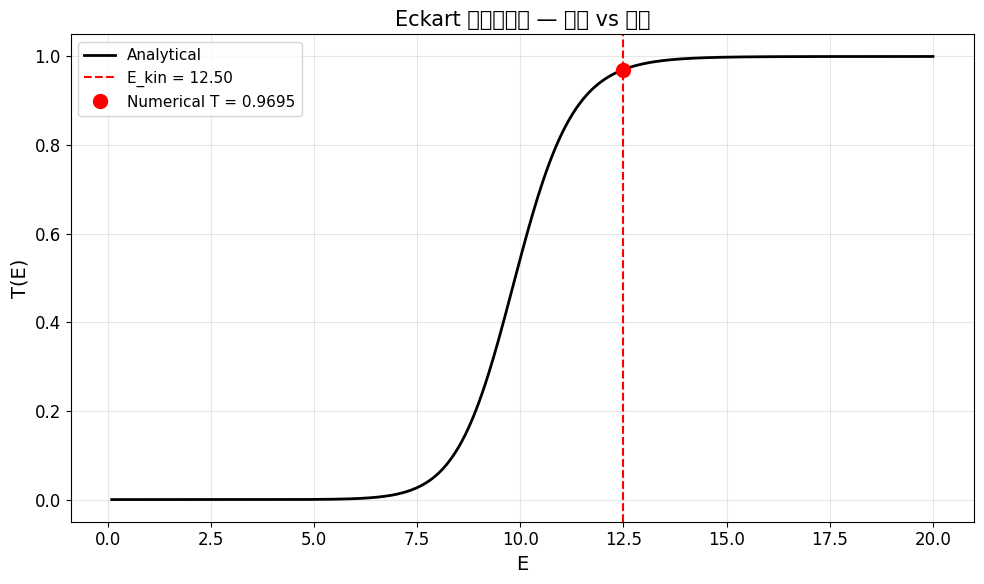

In [8]:
fig = plot_eckart_comparison(result_eckart)
plt.show()

## 3. 多能量点验证

对不同入射能量运行模拟，与解析公式逐点对比

In [9]:
k0_list = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
T_numerical = []
T_analytical = []

for k0 in k0_list:
    p_k = SimParams(V0=10.0, k0=k0, alpha=1.0, sigma=10.0)
    res = propagate(p_k, 'eckart')
    T_num = res.T_values[-1]
    T_ana = eckart_analytical_T_simple(np.array([p_k.E_kinetic]), p_k.V0, p_k.alpha)[0]
    T_numerical.append(T_num)
    T_analytical.append(T_ana)
    print(f'k0 = {k0:.1f}, E = {p_k.E_kinetic:.2f}, T_num = {T_num:.6f}, T_ana = {T_ana:.6f}, error = {abs(T_num-T_ana)/max(T_ana,1e-10)*100:.4f}%')

k0 = 2.0, E = 2.00, T_num = 0.025494, T_ana = 0.000000, error = 11906045.4227%
k0 = 3.0, E = 4.50, T_num = 0.027710, T_ana = 0.000115, error = 24069.9979%
k0 = 4.0, E = 8.00, T_num = 0.091878, T_ana = 0.057848, error = 58.8254%
k0 = 5.0, E = 12.50, T_num = 0.969472, T_ana = 0.970483, error = 0.1042%
k0 = 6.0, E = 18.00, T_num = 0.998677, T_ana = 0.999943, error = 0.1266%
k0 = 7.0, E = 24.50, T_num = 0.988144, T_ana = 1.000000, error = 1.1856%
k0 = 8.0, E = 32.00, T_num = 0.851947, T_ana = 1.000000, error = 14.8053%


C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3438079823.py:12: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3438079823.py:12: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3438079823.py:12: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3438079823.py:12: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3438079823.py:12: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3438079823.py:12: UserWarning: Glyph 35299 (\

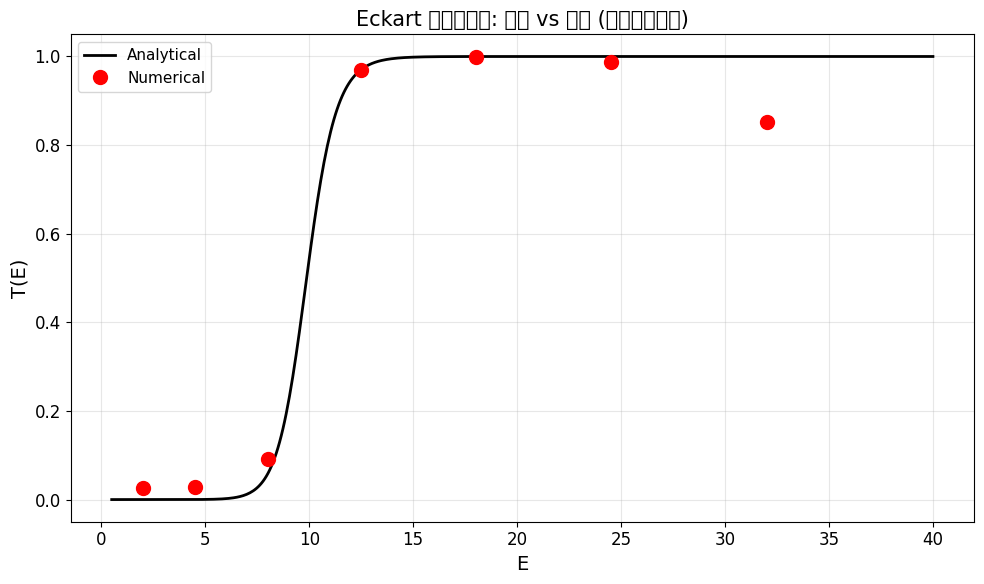

In [10]:
E_list = [0.5 * k**2 for k in k0_list]

fig, ax = plt.subplots(figsize=(10, 6))
E_fine = np.linspace(0.5, 40, 500)
T_fine = eckart_analytical_T_simple(E_fine, 10.0, 1.0)
ax.plot(E_fine, T_fine, 'k-', linewidth=2, label='Analytical')
ax.plot(E_list, T_numerical, 'ro', markersize=10, label='Numerical', zorder=5)
ax.set_xlabel('E')
ax.set_ylabel('T(E)')
ax.set_title('Eckart 势透射系数: 解析 vs 数值 (多能量点验证)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. 不同 α 参数的影响

$\alpha$ 控制势垒宽度：$\alpha$ 越大，势垒越窄，隧穿率越高

C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3564712294.py:13: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3564712294.py:13: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3564712294.py:13: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3564712294.py:13: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_15988\3564712294.py:13: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


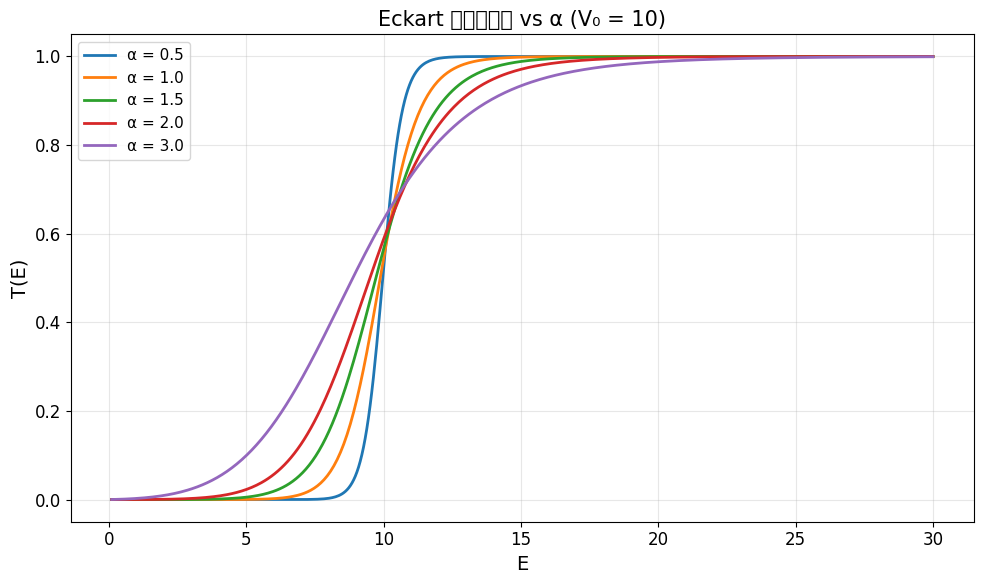

In [11]:
alphas = [0.5, 1.0, 1.5, 2.0, 3.0]

fig, ax = plt.subplots(figsize=(10, 6))
for alpha in alphas:
    E_fine = np.linspace(0.1, 30, 500)
    T_fine = eckart_analytical_T_simple(E_fine, 10.0, alpha)
    ax.plot(E_fine, T_fine, linewidth=2, label=f'α = {alpha}')

ax.set_xlabel('E')
ax.set_ylabel('T(E)')
ax.set_title('Eckart 势透射系数 vs α (V₀ = 10)')
ax.legend()
plt.tight_layout()
plt.show()